# Notebook 2 — Data Preprocessing
**Telecom Customer Churn Project**  
Goal: Import Clean data, encode and scaling features, handle class imbalance, and prepare train/test splits.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings, joblib, os
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',None)

**Importing Cleaned dataset**

In [28]:
df = pd.read_csv('cleaned-customer-churn.csv')

# Drop customerID — not a feature
df.drop(columns=['customerID'], inplace=True)

print("Raw shape:", df.shape)
df.head(5)

Raw shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

# 1. Encode Target Variable

In [30]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})
print("Churn value counts:")
print(df['Churn'].value_counts())

Churn value counts:
Churn
0    5163
1    1869
Name: count, dtype: int64


## 2. Feature Engineering

In [31]:

# Tenure Groups
df['TenureGroup']=pd.cut(df['tenure'],
                         bins=[0,12,24,36,48,60,72],
                         labels=['0-12','13-24','25-36','37-48','49-60','61-72'])

# Number of services subscribed
service_cols=['PhoneService','OnlineSecurity','OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['ServicesCount'] =df['ServicesCount'] = (df[service_cols] == 'Yes').sum(axis=1)

# Average monthly spend proxy
df['AvgMonthlySpend'] = np.where(df['tenure'] > 0,
                                   df['TotalCharges'] / df['tenure'],
                                   df['MonthlyCharges'])

print("New features added: TenureGroup, ServicesCount, AvgMonthlySpend")
print(df[['ServicesCount', 'AvgMonthlySpend']].describe())


New features added: TenureGroup, ServicesCount, AvgMonthlySpend
       ServicesCount  AvgMonthlySpend
count    7032.000000      7032.000000
mean        2.941411        64.799424
std         1.843695        30.185891
min         0.000000        13.775000
25%         1.000000        36.179891
50%         3.000000        70.373239
75%         4.000000        90.179560
max         7.000000       121.400000


### **Reason behind Creating new Features**

1. **TenureGroup** : Customer tenure is a continuous variable ranging from new customers to long-term subscribers. Grouping tenure into intervals helps identify customer lifecycle stages and makes it easier to analyze churn behavior across different customer segments.
   
3. **ServicesCount** :Instead of analyzing each subscribed service separately, a single feature was created to represent the total number of services a customer uses.
4. **AvgMonthlySpend**: This feature estimates the customer's average spending per month by dividing cumulative charges (TotalCharges) by tenure. 

## 3. Encode Categorical Variables

**Observing The Categorical Columns**

In [24]:
cat_cols=['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'OnlineSecurity','MultipleLines', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'InternetService', 'Contract','PaymentMethod', 'TenureGroup']
for col in cat_cols:
    print(f"{col:<20} :",df[col].unique())

gender               : ['Female' 'Male']
Partner              : ['Yes' 'No']
Dependents           : ['No' 'Yes']
PhoneService         : ['No' 'Yes']
PaperlessBilling     : ['Yes' 'No']
OnlineSecurity       : ['No' 'Yes' 'No internet service']
MultipleLines        : ['No phone service' 'No' 'Yes']
OnlineBackup         : ['Yes' 'No' 'No internet service']
DeviceProtection     : ['No' 'Yes' 'No internet service']
TechSupport          : ['No' 'Yes' 'No internet service']
StreamingTV          : ['No' 'Yes' 'No internet service']
StreamingMovies      : ['No' 'Yes' 'No internet service']
InternetService      : ['DSL' 'Fiber optic' 'No']
Contract             : ['Month-to-month' 'One year' 'Two year']
PaymentMethod        : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TenureGroup          : ['0-12', '25-36', '37-48', '13-24', '61-72', '49-60']
Categories (6, object): ['0-12' < '13-24' < '25-36' < '37-48' < '49-60' < '61-72']


In [32]:
# Binary columns (Yes/No, Male/Female)
# Note: 'No internet service' and 'No phone service' are treated as 'No'
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0,
              'No internet service': 0, 'No phone service': 0}

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'OnlineSecurity','MultipleLines', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = df[col].map(binary_map).fillna(df[col])

# Multi-category columns — One-Hot Encoding
ohe_cols = ['InternetService', 'Contract',
            'PaymentMethod', 'TenureGroup']

df = pd.get_dummies(df, columns=ohe_cols, drop_first=False)
# Convert all bool columns to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print("Shape after encoding:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape after encoding: (7032, 35)

Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'ServicesCount', 'AvgMonthlySpend', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TenureGroup_0-12', 'TenureGroup_13-24', 'TenureGroup_25-36', 'TenureGroup_37-48', 'TenureGroup_49-60', 'TenureGroup_61-72']


### Notes 
Machine learning algorithms require numerical input. Therefore, categorical variables were transformed into numerical representations using Binary Encoding and One-Hot Encoding.
   

In [33]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,ServicesCount,AvgMonthlySpend,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_0-12,TenureGroup_13-24,TenureGroup_25-36,TenureGroup_37-48,TenureGroup_49-60,TenureGroup_61-72
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,1,29.850000,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,3,55.573529,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,3,54.075000,1,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,3,40.905556,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,1,75.825000,0,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0


## 4. Train / Test Split

In [34]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")
print(f"Test  churn rate: {y_test.mean()*100:.1f}%")

Train: (5625, 34)  |  Test: (1407, 34)
Train churn rate: 26.6%
Test  churn rate: 26.6%


## 5. Feature Scaling

In [35]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'ServicesCount']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("Scaling done. Sample scaled values:")
X_train[num_cols].describe().round(3)

Scaling done. Sample scaled values:


,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,ServicesCount
count,5625.000,5625.000,5625.000,5625.000,5625.000
mean,-0.000,0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-1.286,-1.548,-1.003,-1.695,-1.608
25%,-0.960,-0.970,-0.830,-0.940,-1.065
50%,-0.145,0.186,-0.392,0.189,0.022
75%,0.955,0.832,0.659,0.841,0.565
max,1.607,1.782,2.805,1.866,2.194


**Why Scaling Was Applied**

Feature scaling standardizes numerical variables to a comparable range so that each feature contributes more fairly during model training.

## 6. Handle Class Imbalance with SMOTE

**Objective**

The target variable (Churn) is imbalanced, with significantly fewer churned customers than non-churned customers. Such imbalance can cause machine learning models to become biased toward the majority class, resulting in poor detection of customers who are likely to churn.

Before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


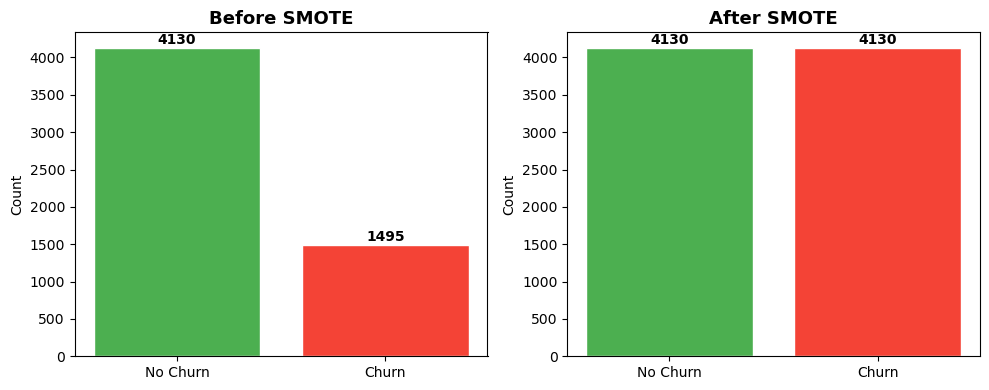

In [36]:

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_data, title in zip(axes, [y_train, y_train_sm], ['Before SMOTE', 'After SMOTE']):
    counts = pd.Series(y_data).value_counts()
    ax.bar(['No Churn', 'Churn'], counts.values, color=['#4CAF50', '#F44336'], edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v+50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing_smote.png', bbox_inches='tight')
plt.show()

**Insight**

The original dataset exhibited a significant class imbalance, with only 1,495 churned customers compared to 4,130 non-churned customers. To mitigate model bias toward the majority class, SMOTE was applied to the training data, increasing the number of churn observations to match the non-churn class. This resulted in a balanced 50:50 class distribution, enabling the model to learn churn patterns more effectively and improving its ability to identify customers at risk of leaving.

## 7. Save Processed Data

In [37]:

os.makedirs('artifacts', exist_ok=True)

# Save splits
X_train_sm.to_csv('artifacts/X_train.csv', index=False)
X_test.to_csv('artifacts/X_test.csv', index=False)
pd.Series(y_train_sm).to_csv('artifacts/y_train.csv', index=False)
y_test.to_csv('artifacts/y_test.csv', index=False)

# Save scaler
joblib.dump(scaler, 'artifacts/scaler.pkl')
joblib.dump(list(X.columns), 'artifacts/feature_names.pkl')

print("✅ Saved to artifacts/:")
print("   X_train.csv, X_test.csv, y_train.csv, y_test.csv")
print("   scaler.pkl, feature_names.pkl")
print(f"\nFinal feature count: {X_train_sm.shape[1]}")

✅ Saved to artifacts/:
   X_train.csv, X_test.csv, y_train.csv, y_test.csv
   scaler.pkl, feature_names.pkl

Final feature count: 34
